# Task 1 [2 points]


1. Download and upload data from the category Sports and Outdoors:
https://cseweb.ucsd.edu/ jmcauley/datasets/amazon_v2/. Process the reviews into a pd.DataFrame
with columns [’user_id’, ’asin’, ’rating’, ’timestamp’]. Take care of the memory
usage of your implementation.


In [1]:
from pathlib import Path
import gc
import pandas as pd

REVIEWS_JSON = Path("data/Sports_and_Outdoors.json")

def load_reviews_naive(path):
    df = pd.read_json(
        path,
        lines=True,
        dtype={
            "reviewerID": "string",
            "asin": "string",
            "overall": "float32",
            "unixReviewTime": "int64",
        },
    )[["reviewerID", "asin", "overall", "unixReviewTime"]].rename(
        columns={
            "reviewerID": "user_id",
            "overall": "rating",
            "unixReviewTime": "timestamp",
        }
    )
    df["user_id"] = df["user_id"].astype("category")
    df["asin"] = df["asin"].astype("category")
    return df

def load_reviews_chunked(path, chunk_size=100000):
    required_cols = ["reviewerID", "asin", "overall", "unixReviewTime"]
    chunks = []

    # print("Processing chunks: ", end="")
    for i, chunk in enumerate(pd.read_json(path, lines=True, chunksize=chunk_size)):
        chunk = chunk[required_cols].rename(
            columns={
                "reviewerID": "user_id",
                "overall": "rating",
                "unixReviewTime": "timestamp",
            }
        )

        chunk["rating"] = chunk["rating"].astype("float32")
        chunk["timestamp"] = chunk["timestamp"].astype("int64")
        chunks.append(chunk)

        # if i % 10 == 0:
            # print(i, end=" ")
    # print()

    df = pd.concat(chunks, ignore_index=True)
    df["user_id"] = df["user_id"].astype("category")
    df["asin"] = df["asin"].astype("category")

    # release temporary chunk objects
    del chunks
    try:
        del chunk
    except NameError:
        pass
    gc.collect()

    return df


def test_loader(loader):
    print(f"Testing loader: {loader.__name__}")

    time_start = pd.Timestamp.now()
    df = loader(REVIEWS_JSON)
    time_end = pd.Timestamp.now()

    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
    print(f"Loaded {len(df)} rows with columns: {list(df.columns)}")
    print(f"Time: {(time_end - time_start).total_seconds():.2f} seconds")
    print(f"Memory usage: {mem_mb:.2f} MB")
    print(f"Loaded {len(df)} rows with columns: {list(df.columns)}")
    print (f"Unique users: {df['user_id'].nunique()}")
    print (f"Unique items: {df['asin'].nunique()}")
    print(df.dtypes)
    print(df.head())

    return df


reviews_df = test_loader(load_reviews_chunked)
print()
# reviews_df = test_loader(load_reviews_naive)

Testing loader: load_reviews_chunked
Processing chunks: 0 10 
Loaded 12980837 rows with columns: ['user_id', 'asin', 'rating', 'timestamp']
Time: 135.45 seconds
Memory usage: 992.81 MB
Loaded 12980837 rows with columns: ['user_id', 'asin', 'rating', 'timestamp']
Unique users: 6703391
Unique items: 957764
user_id      category
asin         category
rating        float32
timestamp       int64
dtype: object
          user_id        asin  rating   timestamp
0  A23K73OVXJ04EG  0000031895     5.0  1391212800
1  A2681T699HV6H1  0000031895     4.0  1384905600
2  A374PA18DCGS5Y  0000031895     1.0  1477008000
3  A14PVW2N5YBWSA  0000031895     5.0  1476748800
4  A2KWBC44QI2567  0000031895     1.0  1476662400



2. What is the 5-core version?


5-core is version filtered version to include only users and items that have at least 5 interactions

3. Provide a basic data analysis for the full variant and the 5-core version:
- (a) number of interactions for each item (sort the counts for readability),
- (b) the distribution of users’ number of interactions,
- (c) calculate the sparsity (how many of the possible user-item pairs are present in the data),
- (d) check for duplicates of contradictory data,
- (e) other plots that you find interesting.


Processing chunks: 0 

========== FULL ========== 

(b) User interactions distribution:
count    6.703391e+06
mean     1.936458e+00
std      2.683295e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      4.330000e+02
dtype: float64

(c) Sparsity:
users = 6703391, items = 957764
density = 12601954/6420266577724 = 0.00000196
sparsity = 0.99999804

(d) Duplicate/contradiction checks:
exact duplicates (same user,item,rating,timestamp): 369145
contradictory same-timestamp ratings: 1059
same user-item with different ratings over time: 3074

========== 5-CORE ========== 

(b) User interactions distribution:
count    332447.000000
mean          8.542535
std           6.518266
min           2.000000
25%           5.000000
50%           7.000000
75%           9.000000
max         371.000000
dtype: float64

(c) Sparsity:
users = 332447, items = 104687
density = 2679607/34802879089 = 0.00007699
sparsity = 0.99992301

(d) Duplicate/contradiction checks

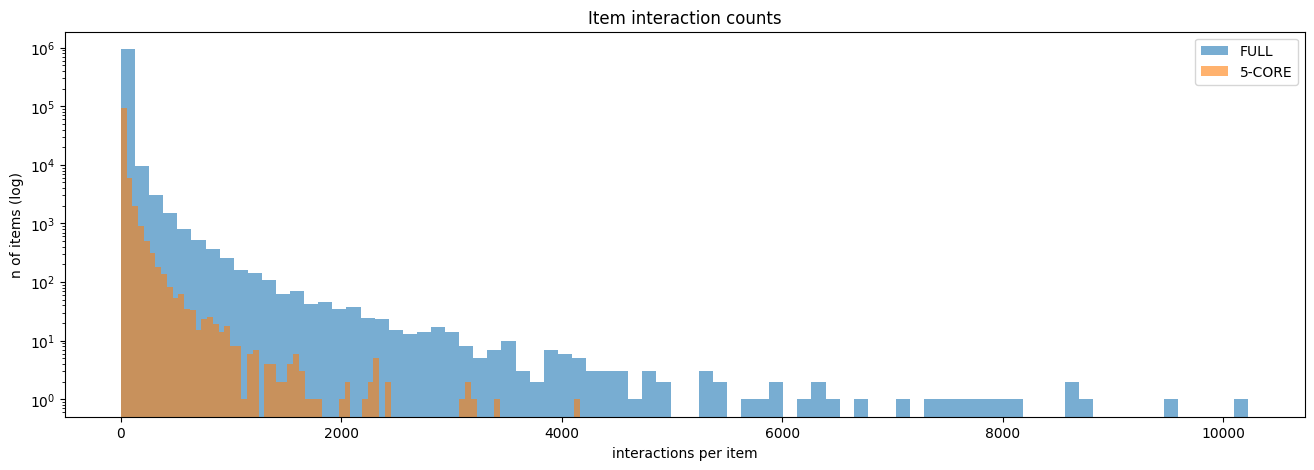

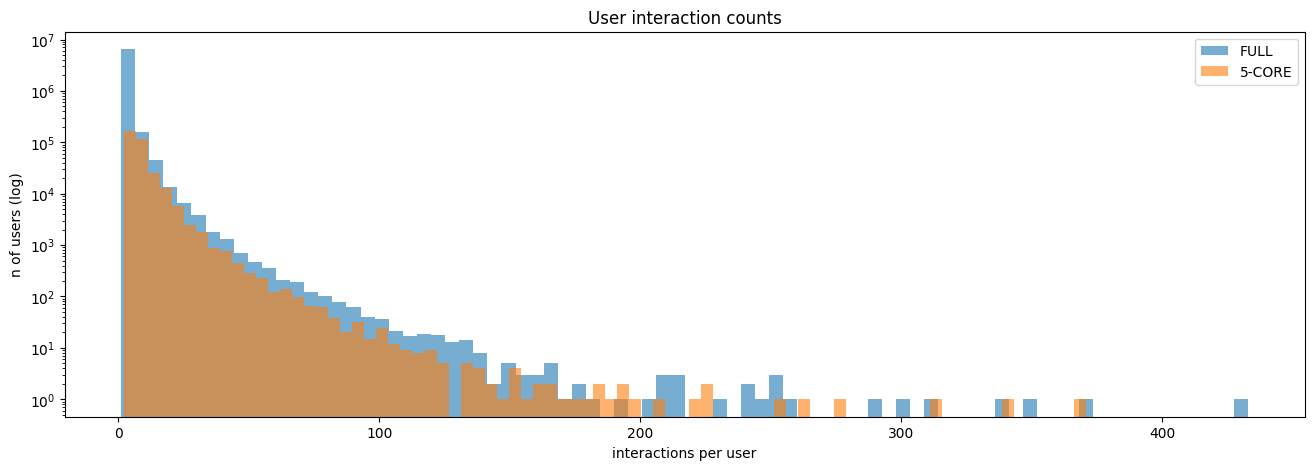

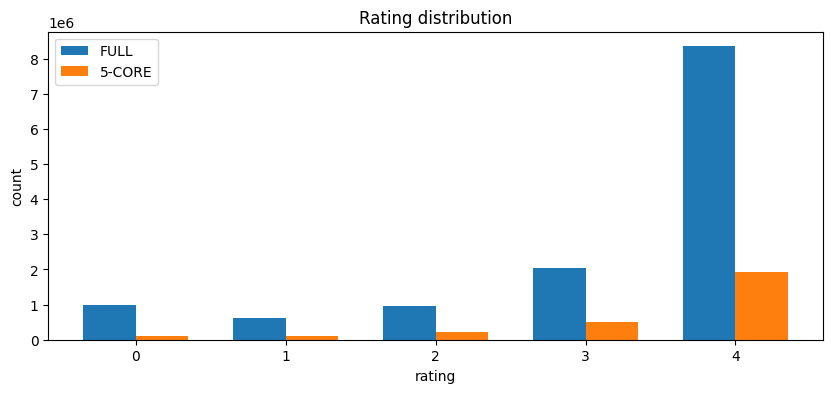

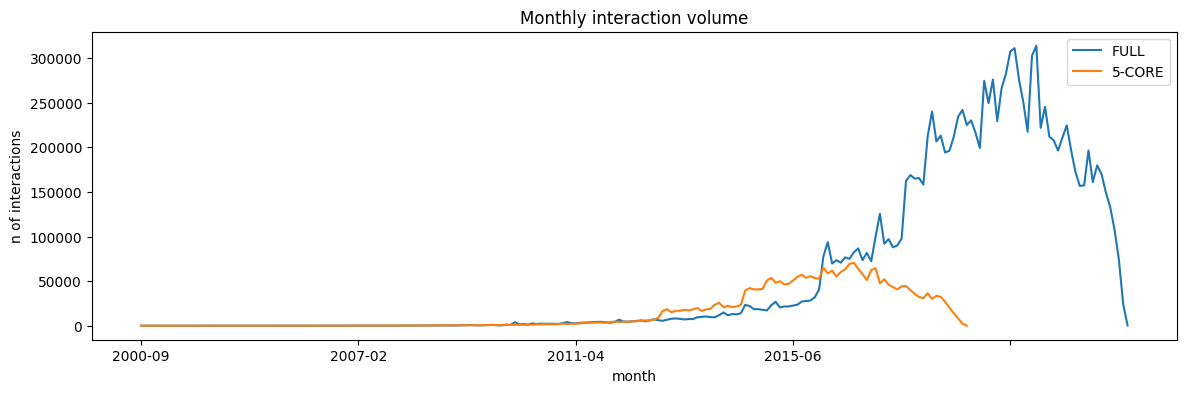

In [13]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def load_reviews(path):
    return load_reviews_chunked(path)

def plot_n_interactions_per_item(item_counts_list, names):
    plt.figure(figsize=(16, 5))
    for counts, name in zip(item_counts_list, names):
        plt.hist(counts, bins=80, alpha=0.6, label=name)
    plt.title("Item interaction counts")
    plt.xlabel("interactions per item")
    plt.ylabel("n of items (log)")
    plt.yscale("log")
    plt.legend()
    plt.show()

def plot_n_interactions_per_user(user_counts_list, names):
    plt.figure(figsize=(16, 5))
    for counts, name in zip(user_counts_list, names):
        plt.hist(counts, bins=80, alpha=0.6, label=name)
    plt.title("User interaction counts")
    plt.xlabel("interactions per user")
    plt.ylabel("n of users (log)")
    plt.yscale("log")
    plt.legend()
    plt.show()

def analyze(df, name, plot=True):
    print(f"\n========== {name} ========== ")

    # - (a) number of interactions for each item (sort the counts for readability),
    item_counts = df.groupby("asin", observed=True).size().sort_values(ascending=False)

    if plot:
        plot_n_interactions_per_item([item_counts], [name])

    # - (b) the distribution of users’ number of interactions,
    user_counts = df.groupby("user_id", observed=True).size()
    print("\n(b) User interactions distribution:")
    print(user_counts.describe())

    if plot:
        plot_n_interactions_per_user([user_counts], [name])

    # - (c) calculate the sparsity (how many of the possible user-item pairs are present in the data),
    n_users = df["user_id"].nunique()
    n_items = df["asin"].nunique()
    observed_pairs = df[["user_id", "asin"]].drop_duplicates().shape[0]
    possible_pairs = n_users * n_items
    density = observed_pairs / possible_pairs
    sparsity = 1.0 - density

    print("\n(c) Sparsity:")
    print(f"users = {n_users}, items = {n_items}")
    print(f"density = {observed_pairs}/{possible_pairs} = {density:.8f}")
    print(f"sparsity = {sparsity:.8f}")

    # - (d) check for duplicates of contradictory data,
    exact_dups = df.duplicated(subset=["user_id", "asin", "rating", "timestamp"]).sum()
    contradictory_same_time = (
        df.groupby(["user_id", "asin", "timestamp"], observed=True)["rating"]
        .nunique()
        .gt(1)
        .sum()
    )
    changed_rating_over_time = (
        df.groupby(["user_id", "asin"], observed=True)["rating"]
        .nunique()
        .gt(1)
        .sum()
    )

    print("\n(d) Duplicate/contradiction checks:")
    print(f"exact duplicates (same user,item,rating,timestamp): {exact_dups}")
    print(f"contradictory same-timestamp ratings: {contradictory_same_time}")
    print(f"same user-item with different ratings over time: {changed_rating_over_time}")

    # misc
    monthly_counts = (
        pd.to_datetime(df["timestamp"], unit="s")
        .dt.to_period("M")
        .astype(str)
        .value_counts()
        .sort_index()
    )

    return {
        "item_counts": item_counts,
        "user_counts": user_counts,
        "rating_counts": df["rating"].value_counts().sort_index(),
        "monthly_counts": monthly_counts,
    }


full_path = Path("data/Sports_and_Outdoors.json")
core_path = Path("data/Sports_and_Outdoors_5.json")

full_df = reviews_df if "reviews_df" in globals() else load_reviews(full_path)
core_df = load_reviews(core_path)

full_stats = analyze(full_df, "FULL", plot=False)
core_stats = analyze(core_df, "5-CORE", plot=False)

plot_n_interactions_per_item([full_stats["item_counts"], core_stats["item_counts"]], ["FULL", "5-CORE"])
plot_n_interactions_per_user([full_stats["user_counts"], core_stats["user_counts"]], ["FULL", "5-CORE"])

# rating
plt.figure(figsize=(10, 4))
ratings = sorted(set(full_stats["rating_counts"].index).union(set(core_stats["rating_counts"].index)))
full_rc = [full_stats["rating_counts"].get(r, 0) for r in ratings]
core_rc = [core_stats["rating_counts"].get(r, 0) for r in ratings]
x = np.arange(len(ratings))
w = 0.35
plt.bar(x - w / 2, full_rc, width=w, label="FULL")
plt.bar(x + w / 2, core_rc, width=w, label="5-CORE")
plt.xlabel("rating")
plt.ylabel("count")
plt.legend()
plt.show()

# monthly interaction
plt.figure(figsize=(14, 4))
full_stats["monthly_counts"].plot(label="FULL")
core_stats["monthly_counts"].plot(label="5-CORE")
plt.title("Monthly interaction volume")
plt.xlabel("month")
plt.ylabel("n of interactions")
plt.legend()
plt.show()

4. Consider the following train-test split procedures. What are their advantages and disadvan-
tages? Think of user and item representation, biases, leakage, and suitability for the ranking
task.
- Randomly select 20% of all interactions.
- Randomly select 20% of users and put all their interactions in the test set.
- Select 20% of interactions for each user at random.
- Select the most recent 20% of interactions for each user.
- Select a fixed number of the most recent interactions for each user to obtain around 20%
of the data.
- Select the most recent 20% of all interactions.


### Randomly select 20% of all interactions
**Advantages**
- simple
- popular (easier to compare)
- equal coverage of users and items in both train and test

**Disadvantages**
- temporal leakage - ttrain can contain future interactions, helping predict past ones
- shopaholic users can dominate metrics due to more test points

### Randomly select 20% of users and put all their interactions in test
**Advantages**
- user-level generalization - model must learn to represent unseen users (good for cold-start)
- no future-interaction leakage for predicted users

**Disadvantages**
- we still have future interaction leakage
- single-time users can dominate dataset


### Select 20% of interactions for each user at random
**Advantages**
- every user appears in both train and test (user representation is balanced)
- reduces dominance of very active users compared with global random split

**Disadvantages**
- temporal leakage
- can leak short-term preferences and make metrics look better than they really are
- rarely interacted items may still have weak train support


### Select the most recent 20% of interactions for each user
**Advantages**
- chronologically correct per user: train uses past, test uses future
- good for practical ranking/next-item recommendation
- every user is represented in train and test

**Disadvantages**
- bad for cold start - new users have no history
- users with very few interactions produce tiny/unstable/unconclusive data

### Select a fixed number of most recent interactions per user (to get ~20% total)
**Advantages**
- chronological
- each user contributes tests, consistent per-user test size

**Disadvantages**
- low-activity users may contribute very little train data, and lots of test data (unconclusive results)
- low-activity users may overweight metrics
- unbalanced user representattion

### Select the most recent 20% of all interactions (global time cutoff)
**Advantages**
- chronological, strongest anti-leakage in time
- may capture trends in time (seasonality)

**Disadvantages**
- some users may be underrepresented


5. Use the 5-core variant. Perform a train-test split by selecting the 2 most recent items for each
user for testing.


In [ ]:
core_df_local = core_df.copy() if "core_df" in globals() else load_reviews(Path("data/Sports_and_Outdoors_5.json"))

# Keep original row id for strict train/test disjointness checks.
df = core_df_local.reset_index(drop=False).rename(columns={"index": "row_id"})

# Sort so "most recent" means largest timestamp (ties broken by row_id).
df = df.sort_values(["user_id", "timestamp", "row_id"], ascending=[True, False, False])

# Rank interactions within each user by recency: 0,1,2,...
df["rank_recent"] = df.groupby("user_id", observed=True).cumcount()

# Put top-2 recent interactions per user into test.
test_mask = df["rank_recent"] < 2
test_df = df.loc[test_mask, ["user_id", "asin", "rating", "timestamp", "row_id"]].copy()
train_df = df.loc[~test_mask, ["user_id", "asin", "rating", "timestamp", "row_id"]].copy()

# Sanity checks
assert set(train_df["row_id"]).isdisjoint(set(test_df["row_id"]))
per_user_test_counts = test_df.groupby("user_id", observed=True).size()
assert per_user_test_counts.max() <= 2

n_users = df["user_id"].nunique()
n_interactions = len(df)
n_test = len(test_df)
n_train = len(train_df)

print(f"Users: {n_users}")
print(f"Interactions total: {n_interactions}")
print(f"Train interactions: {n_train}")
print(f"Test interactions: {n_test}")
print(f"Test ratio: {n_test / n_interactions:.4f}")
print("\nPer-user test interactions (describe):")
print(per_user_test_counts.describe())

# Optional: remove helper columns from split-ready outputs
train_split = train_df.drop(columns=["row_id"]).reset_index(drop=True)
test_split = test_df.drop(columns=["row_id"]).reset_index(drop=True)

print("\nTrain preview:")
display(train_split.head())
print("Test preview:")
display(test_split.head())

Users: 332447
Interactions total: 2839940
Train interactions: 2175046
Test interactions: 664894
Test ratio: 0.2341

Per-user test interactions (describe):
count    332447.0
mean          2.0
std           0.0
min           2.0
25%           2.0
50%           2.0
75%           2.0
max           2.0
dtype: float64

Train preview:


,user_id,asin,rating,timestamp
0,A0001528BGUBOEVR6T5U,B004E4AVY8,5.0,1439337600
1,A0001528BGUBOEVR6T5U,B0034XCI82,5.0,1439337600
2,A0001528BGUBOEVR6T5U,B0031YS5UY,5.0,1439337600
3,A0001528BGUBOEVR6T5U,B0009PUQ8M,5.0,1439337600
4,A0001528BGUBOEVR6T5U,B004I7D1WA,5.0,1410480000


Test preview:


,user_id,asin,rating,timestamp
0,A0001528BGUBOEVR6T5U,B012ZIGVXE,3.0,1478131200
1,A0001528BGUBOEVR6T5U,B007ZYH4BM,5.0,1439337600
2,A0024836TBQJ1WBE4VDY,B01AISP1KW,1.0,1530316800
3,A0024836TBQJ1WBE4VDY,B001GH4WD2,5.0,1527465600
4,A0029274J35Q1MYNKUWO,B0009349R8,5.0,1510790400


6. Think about how you can transform the data into boolean feedback.
You can obtain a point for the implementation and a point for the comments and answers

### Task 6 answer: transforming ratings into boolean feedback

For implicit recommenders, we model only whether a user interacted positively with an item (`1`) or not observed (`0`, unknown).
A practical transformation for 1-5 star data is:
- **Positive rule**: `rating >= 4` -> `1`, else drop from positives.
- Merge repeated user-item events into one positive pair (keep strongest/latest signal).
- Treat missing user-item pairs as unlabeled negatives during training (sample negatives).

Why this is useful:
- Aligns with top-N ranking objectives (click/buy-like behavior).
- Reduces rating-scale noise and user calibration differences.
- Enables standard implicit-feedback models (BPR, ALS implicit, logistic MF).

Main caveat:
- Lower ratings are not always true negatives; they can be ignored rather than forced to `0`.

In [ ]:
df_core = core_df.copy() if "core_df" in globals() else load_reviews(Path("data/Sports_and_Outdoors_5.json"))

# 1) Define positives from explicit ratings.
# Common choice: ratings >= 4 are positive implicit events.
threshold = 4.0
df_pos = df_core.loc[df_core["rating"] >= threshold, ["user_id", "asin", "timestamp", "rating"]].copy()

# 2) Collapse repeated interactions to one binary event per (user, item).
df_pos = df_pos.sort_values(["user_id", "asin", "timestamp"]).drop_duplicates(["user_id", "asin"], keep="last")

# 3) Create final boolean feedback table.
implicit_df = df_pos[["user_id", "asin"]].copy()
implicit_df["feedback"] = 1
implicit_df["feedback"] = implicit_df["feedback"].astype("int8")

# Basic diagnostics
n_users = df_core["user_id"].nunique()
n_items = df_core["asin"].nunique()
n_total = len(df_core)
n_pos_raw = (df_core["rating"] >= threshold).sum()
n_pos_unique = len(implicit_df)
density = n_pos_unique / (n_users * n_items)

print("Boolean feedback transformation summary")
print("=" * 45)
print(f"Threshold for positive: rating >= {threshold}")
print(f"Original interactions: {n_total}")
print(f"Raw positive interactions: {n_pos_raw}")
print(f"Unique positive user-item pairs: {n_pos_unique}")
print(f"Users: {n_users}, items: {n_items}")
print(f"Implicit matrix density: {density:.8f}")
print(f"Implicit matrix sparsity: {1 - density:.8f}")

print("\nSample of implicit data:")
display(implicit_df.head())

# Optional variant for very implicit settings: every interaction is positive.
implicit_all = df_core[["user_id", "asin"]].drop_duplicates().copy()
implicit_all["feedback"] = 1
implicit_all["feedback"] = implicit_all["feedback"].astype("int8")

print("\nAlternative variant (all interactions are positive):")
print(f"Unique pairs: {len(implicit_all)}")
print("Use this if the task is pure implicit recommendation without rating semantics.")

Boolean feedback transformation summary
Threshold for positive: rating >= 4.0
Original interactions: 2839940
Raw positive interactions: 2416931
Unique positive user-item pairs: 2280461
Users: 332447, items: 104687
Implicit matrix density: 0.00006553
Implicit matrix sparsity: 0.99993447

Sample of implicit data:


,user_id,asin,feedback
32595,A0001528BGUBOEVR6T5U,B0002NY6SW,1
71996,A0001528BGUBOEVR6T5U,B0009PUQ8M,1
120740,A0001528BGUBOEVR6T5U,B000E7SY02,1
778828,A0001528BGUBOEVR6T5U,B001QBJT5Y,1
878743,A0001528BGUBOEVR6T5U,B002M4110K,1



Alternative variant (all interactions are positive):
Unique pairs: 2679607
Use this if the task is pure implicit recommendation without rating semantics.


# Task 2 [3 points]